# Phase II Paired App Analysis

This notebook compares the same applications across Google Play Store and Apple App Store.

The analysis focuses on paired app-level differences in ratings, review length, low-signal reviews, timestamp coverage, and metadata availability.

The goal is to identify meaningful cross-platform patterns while avoiding conclusions that may be driven by differences in review time windows.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Locate project root
ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

APPLE_PATH = ROOT / "data" / "processed" / "apple_store_analysis.csv"
GOOGLE_PATH = ROOT / "data" / "processed" / "google_play_analysis.csv"

apple = pd.read_csv(APPLE_PATH)
google = pd.read_csv(GOOGLE_PATH)

# Parse dates
apple["review_date"] = pd.to_datetime(
    apple["review_date"],
    errors="coerce",
    utc=True
)

google["review_date"] = pd.to_datetime(
    google["review_date"],
    errors="coerce",
    utc=True
)

# Review length
apple["review_length"] = (
    apple["review_text"]
    .fillna("")
    .str.len()
)

google["review_length"] = (
    google["review_text"]
    .fillna("")
    .str.len()
)

print("Apple rows:", len(apple))
print("Google Play rows:", len(google))

Apple rows: 13599
Google Play rows: 13599


## 1. Paired Dataset Validation

In [3]:
apple_apps = set(apple["app_name"].unique())
google_apps = set(google["app_name"].unique())

shared_apps = sorted(
    apple_apps.intersection(google_apps)
)

print("Apple apps:", len(apple_apps))
print("Google Play apps:", len(google_apps))
print("Shared apps:", len(shared_apps))

print("\nApps only in Apple:")
print(sorted(apple_apps - google_apps))

print("\nApps only in Google Play:")
print(sorted(google_apps - apple_apps))

Apple apps: 28
Google Play apps: 28
Shared apps: 28

Apps only in Apple:
[]

Apps only in Google Play:
[]


## 2. Cross-Platform Rating Differences by App

In [4]:
apple_rating_by_app = (
    apple.groupby("app_name")["rating"]
    .mean()
    .rename("Apple Rating")
)

google_rating_by_app = (
    google.groupby("app_name")["rating"]
    .mean()
    .rename("Google Play Rating")
)

rating_gap = pd.concat(
    [apple_rating_by_app, google_rating_by_app],
    axis=1
)

rating_gap["Difference"] = (
    rating_gap["Google Play Rating"]
    - rating_gap["Apple Rating"]
)

rating_gap["Absolute Difference"] = (
    rating_gap["Difference"].abs()
)

rating_gap = (
    rating_gap
    .sort_values(
        "Absolute Difference",
        ascending=False
    )
)

display(rating_gap.round(2))

,Apple Rating,Google Play Rating,Difference,Absolute Difference
app_name,,,,
Airbnb,1.27,3.76,2.49,2.49
Microsoft OneDrive,1.93,3.79,1.87,1.87
PayPal,1.71,3.43,1.72,1.72
Pinterest,2.69,4.20,1.51,1.51
YouTube Music,2.31,3.74,1.44,1.44
Venmo,1.68,2.94,1.26,1.26
Discord,2.46,3.49,1.03,1.03
TikTok,2.83,3.84,1.01,1.01
Instagram,2.77,3.78,1.01,1.01


In [5]:
top_rating_gaps = (
    rating_gap
    .head(10)
    .copy()
)

display(top_rating_gaps.round(2))

,Apple Rating,Google Play Rating,Difference,Absolute Difference
app_name,,,,
Airbnb,1.27,3.76,2.49,2.49
Microsoft OneDrive,1.93,3.79,1.87,1.87
PayPal,1.71,3.43,1.72,1.72
Pinterest,2.69,4.20,1.51,1.51
YouTube Music,2.31,3.74,1.44,1.44
Venmo,1.68,2.94,1.26,1.26
Discord,2.46,3.49,1.03,1.03
TikTok,2.83,3.84,1.01,1.01
Instagram,2.77,3.78,1.01,1.01


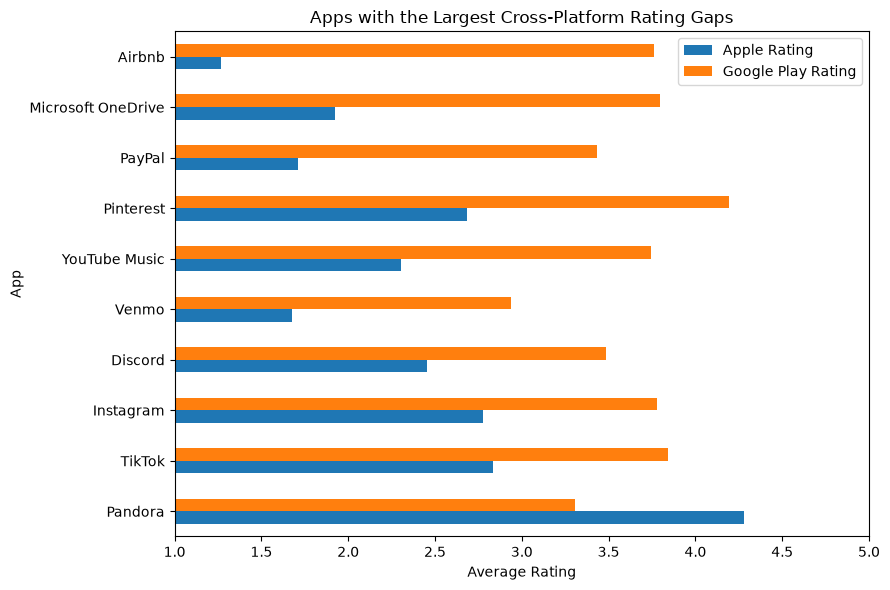

In [7]:
plot_data = (
    top_rating_gaps
    .sort_values(
        "Absolute Difference",
        ascending=True
    )
)

plot_data[
    ["Apple Rating", "Google Play Rating"]
].plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Apps with the Largest Cross-Platform Rating Gaps")
plt.xlabel("Average Rating")
plt.ylabel("App")
plt.xlim(1, 5)
plt.tight_layout()
plt.show()

### Initial Paired Rating Findings

- Cross-platform rating differences vary substantially by application rather than moving uniformly in one direction.
- The largest observed gaps include Airbnb, Microsoft OneDrive, PayPal, Pinterest, and YouTube Music, all of which have higher average ratings on Google Play in the current matched samples.
- Pandora shows the opposite pattern, with a noticeably higher average rating on Apple App Store.
- These differences should not yet be interpreted as platform effects because the same number of reviews may represent different historical time windows across the two platforms.

## 3. Rating Gaps and Timestamp Coverage

In [8]:
apple_time = (
    apple.groupby("app_name")["review_date"]
    .agg(["min", "max"])
)

google_time = (
    google.groupby("app_name")["review_date"]
    .agg(["min", "max"])
)

apple_time["Apple Coverage Days"] = (
    apple_time["max"] - apple_time["min"]
).dt.total_seconds() / 86400

google_time["Google Coverage Days"] = (
    google_time["max"] - google_time["min"]
).dt.total_seconds() / 86400


time_comparison = pd.DataFrame({
    "Apple Coverage Days": apple_time["Apple Coverage Days"],
    "Google Coverage Days": google_time["Google Coverage Days"]
})


# Measure how different the two time windows are,
# regardless of which platform has the longer window
time_comparison["Coverage Mismatch Ratio"] = (
    time_comparison[
        ["Apple Coverage Days", "Google Coverage Days"]
    ].max(axis=1)
    /
    time_comparison[
        ["Apple Coverage Days", "Google Coverage Days"]
    ].min(axis=1)
)


rating_time_diagnostic = (
    rating_gap
    .join(time_comparison)
)


top_rating_time = (
    rating_time_diagnostic
    .sort_values(
        "Absolute Difference",
        ascending=False
    )
    .head(10)
)

display(top_rating_time.round(2))

,Apple Rating,Google Play Rating,Difference,Absolute Difference,Apple Coverage Days,Google Coverage Days,Coverage Mismatch Ratio
app_name,,,,,,,
Airbnb,1.27,3.76,2.49,2.49,117.80,12.08,9.75
Microsoft OneDrive,1.93,3.79,1.87,1.87,395.01,13.10,30.16
PayPal,1.71,3.43,1.72,1.72,23.11,1.69,13.66
Pinterest,2.69,4.20,1.51,1.51,13.63,2.63,5.19
YouTube Music,2.31,3.74,1.44,1.44,65.09,2.26,28.75
Venmo,1.68,2.94,1.26,1.26,12.03,6.18,1.95
Discord,2.46,3.49,1.03,1.03,9.68,3.19,3.04
TikTok,2.83,3.84,1.01,1.01,4.49,0.77,5.86
Instagram,2.77,3.78,1.01,1.01,4.95,0.24,20.75


### Rating Gap and Time-Window Findings

- Several of the largest rating gaps also occur alongside substantial differences in timestamp coverage.
- Microsoft OneDrive, YouTube Music, Instagram, PayPal, and Airbnb show large cross-platform rating differences, but their matched review samples represent very different historical windows.
- These cases should therefore be interpreted cautiously and not treated as direct platform effects.
- Venmo and Pandora are particularly useful paired-comparison candidates because they show meaningful rating differences while their review time windows are relatively more comparable.
- Pandora is especially notable because it shows the opposite direction from most of the largest gaps, with a higher average rating on Apple App Store than on Google Play.

In [9]:
paired_candidates = rating_time_diagnostic.copy()

def classify_time_mismatch(ratio):
    if ratio <= 2:
        return "Low"
    elif ratio <= 5:
        return "Moderate"
    else:
        return "High"

paired_candidates["Time Mismatch"] = (
    paired_candidates["Coverage Mismatch Ratio"]
    .apply(classify_time_mismatch)
)

paired_candidates["Large Rating Gap"] = (
    paired_candidates["Absolute Difference"] >= 0.75
)

paired_candidates = (
    paired_candidates
    .sort_values(
        "Absolute Difference",
        ascending=False
    )
)

display(
    paired_candidates[
        [
            "Apple Rating",
            "Google Play Rating",
            "Difference",
            "Absolute Difference",
            "Coverage Mismatch Ratio",
            "Time Mismatch",
            "Large Rating Gap"
        ]
    ].round(2)
)

,Apple Rating,Google Play Rating,Difference,Absolute Difference,Coverage Mismatch Ratio,Time Mismatch,Large Rating Gap
app_name,,,,,,,
Airbnb,1.27,3.76,2.49,2.49,9.75,High,True
Microsoft OneDrive,1.93,3.79,1.87,1.87,30.16,High,True
PayPal,1.71,3.43,1.72,1.72,13.66,High,True
Pinterest,2.69,4.20,1.51,1.51,5.19,High,True
YouTube Music,2.31,3.74,1.44,1.44,28.75,High,True
Venmo,1.68,2.94,1.26,1.26,1.95,Low,True
Discord,2.46,3.49,1.03,1.03,3.04,Moderate,True
TikTok,2.83,3.84,1.01,1.01,5.86,High,True
Instagram,2.77,3.78,1.01,1.01,20.75,High,True


In [10]:
strong_candidates = paired_candidates[
    (paired_candidates["Large Rating Gap"]) &
    (paired_candidates["Time Mismatch"] == "Low")
]

display(
    strong_candidates[
        [
            "Apple Rating",
            "Google Play Rating",
            "Difference",
            "Coverage Mismatch Ratio"
        ]
    ].round(2)
)

,Apple Rating,Google Play Rating,Difference,Coverage Mismatch Ratio
app_name,,,,
Venmo,1.68,2.94,1.26,1.95
Pandora,4.28,3.31,-0.98,1.45
Lyft,4.08,3.23,-0.85,1.88


## 4. Paired Rating Distributions for Selected Apps

Venmo, Pandora, and Lyft were selected for deeper paired analysis because they show relatively large cross-platform rating differences while also having comparatively similar review-time coverage.

In [11]:
selected_apps = [
    "Venmo",
    "Pandora",
    "Lyft"
]

rating_distribution_rows = []

for app in selected_apps:

    apple_app = apple[
        apple["app_name"] == app
    ]

    google_app = google[
        google["app_name"] == app
    ]

    for rating in range(1, 6):

        apple_pct = (
            (apple_app["rating"] == rating)
            .mean()
            * 100
        )

        google_pct = (
            (google_app["rating"] == rating)
            .mean()
            * 100
        )

        rating_distribution_rows.append({
            "app_name": app,
            "rating": rating,
            "Apple App Store": apple_pct,
            "Google Play Store": google_pct
        })


paired_rating_distribution = pd.DataFrame(
    rating_distribution_rows
)

display(
    paired_rating_distribution.round(2)
)

,app_name,rating,Apple App Store,Google Play Store
0,Venmo,1,74.8,44.6
1,Venmo,2,7.4,5.2
2,Venmo,3,4.0,3.6
3,Venmo,4,3.0,4.8
4,Venmo,5,10.8,41.8
5,Pandora,1,8.8,30.6
6,Pandora,2,4.0,8.0
7,Pandora,3,7.6,8.0
8,Pandora,4,9.4,7.0
9,Pandora,5,70.2,46.4


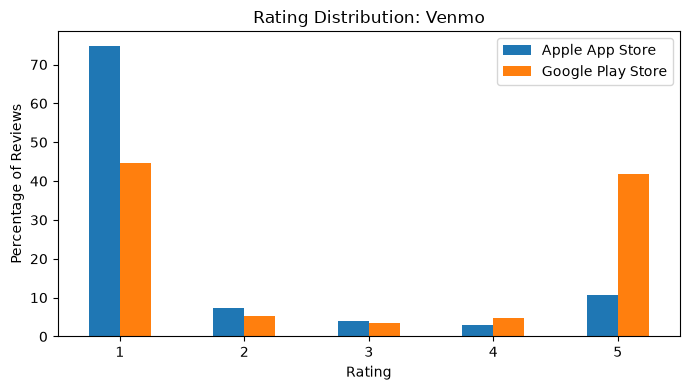

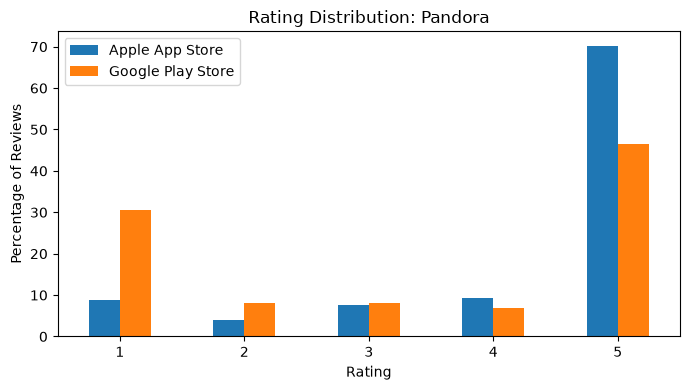

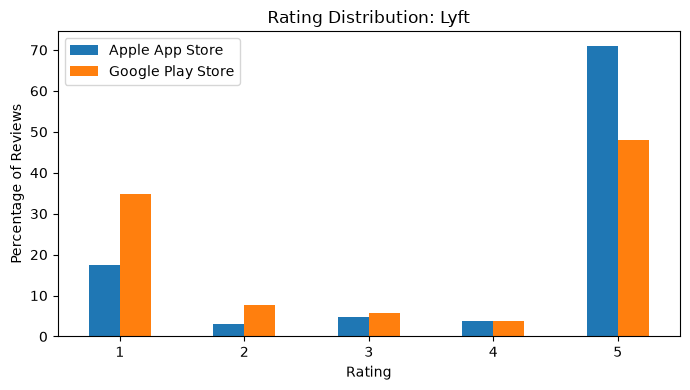

In [12]:
for app in selected_apps:

    plot_data = (
        paired_rating_distribution[
            paired_rating_distribution["app_name"] == app
        ]
        .set_index("rating")[
            ["Apple App Store", "Google Play Store"]
        ]
    )

    plot_data.plot(
        kind="bar",
        figsize=(7, 4)
    )

    plt.title(
        f"Rating Distribution: {app}"
    )

    plt.xlabel("Rating")
    plt.ylabel("Percentage of Reviews")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

### Paired Rating Distribution Findings

- The selected apps show substantial cross-platform differences in the shape of their rating distributions, not only in their average ratings.
- Venmo is considerably more negative in the Apple App Store sample: 74.8% of Apple reviews are 1-star compared with 44.6% on Google Play, while only 10.8% are 5-star compared with 41.8% on Google Play.
- Pandora shows the opposite pattern. Apple reviews are substantially more positive, with 70.2% rated 5 stars compared with 46.4% on Google Play, while Google Play has a much larger share of 1-star reviews.
- Lyft follows a similar pattern to Pandora, with a higher share of 5-star reviews on Apple and a higher share of 1-star reviews on Google Play.
- These results reinforce that cross-platform differences are app-specific rather than consistently favoring one platform.
- From a product perspective, platform-specific review analysis may therefore reveal issues or user experiences that could be hidden by platform-wide averages.
- Although these apps have relatively similar time coverage compared with the other large-gap cases, their review windows are still not identical, so the differences should not be interpreted causally.

## 5. Paired Review Length and Low-Signal Comparison

In [13]:
paired_quality_rows = []

for app in selected_apps:

    apple_app = apple[
        apple["app_name"] == app
    ].copy()

    google_app = google[
        google["app_name"] == app
    ].copy()

    paired_quality_rows.append({
        "app_name": app,
        "Apple Median Length": apple_app["review_length"].median(),
        "Google Median Length": google_app["review_length"].median(),

        "Apple <=20 Char (%)": (
            (apple_app["review_length"] <= 20).mean() * 100
        ),

        "Google <=20 Char (%)": (
            (google_app["review_length"] <= 20).mean() * 100
        ),

        "Apple Repeated Text (%)": (
            apple_app["review_text"].duplicated().mean() * 100
        ),

        "Google Repeated Text (%)": (
            google_app["review_text"].duplicated().mean() * 100
        )
    })


paired_quality = pd.DataFrame(
    paired_quality_rows
).set_index("app_name")

display(
    paired_quality.round(2)
)

,Apple Median Length,Google Median Length,Apple <=20 Char (%),Google <=20 Char (%),Apple Repeated Text (%),Google Repeated Text (%)
app_name,,,,,,
Venmo,148.0,73.0,9.0,22.6,0.6,3.8
Pandora,73.5,60.0,18.2,24.2,0.6,4.0
Lyft,64.0,88.5,23.0,16.8,2.0,2.6


### Paired Review Quality Findings

- Review richness also differs by app and platform rather than following a uniform platform-wide pattern.
- Venmo reviews are substantially longer on Apple App Store than on Google Play, with a median length of 148 versus 73 characters. Apple also has a much lower share of very short Venmo reviews.
- Pandora shows a similar, though smaller, pattern, with somewhat longer and less repetitive reviews on Apple.
- Lyft shows the opposite pattern: Google Play reviews are longer on average, while Apple contains a higher share of very short reviews.
- These results suggest that the usefulness of review text for product diagnosis may vary by both application and platform.
- Product teams may therefore benefit from evaluating feedback quality separately by platform rather than assuming that review volume or rating alone captures the same amount of user insight.

## 6. Detail in Negative Reviews

In [14]:
negative_detail_rows = []

for app in selected_apps:

    apple_negative = apple[
        (apple["app_name"] == app) &
        (apple["rating"] <= 2)
    ]

    google_negative = google[
        (google["app_name"] == app) &
        (google["rating"] <= 2)
    ]

    negative_detail_rows.append({
        "app_name": app,

        "Apple Negative Reviews": len(apple_negative),
        "Google Negative Reviews": len(google_negative),

        "Apple Negative Median Length":
            apple_negative["review_length"].median(),

        "Google Negative Median Length":
            google_negative["review_length"].median(),

        "Apple Negative <=20 Char (%)":
            (apple_negative["review_length"] <= 20).mean() * 100,

        "Google Negative <=20 Char (%)":
            (google_negative["review_length"] <= 20).mean() * 100
    })


negative_detail = (
    pd.DataFrame(negative_detail_rows)
    .set_index("app_name")
)

display(
    negative_detail.round(2)
)

,Apple Negative Reviews,Google Negative Reviews,Apple Negative Median Length,Google Negative Median Length,Apple Negative <=20 Char (%),Google Negative <=20 Char (%)
app_name,,,,,,
Venmo,411,249,167.0,153.0,6.33,5.22
Pandora,64,193,159.0,145.0,4.69,4.15
Lyft,102,212,168.5,181.0,8.82,4.72


### Negative Review Findings

- Negative reviews tend to contain substantially more detail than the overall review population on both platforms.
- Venmo has considerably more negative reviews on Apple App Store than on Google Play (411 vs. 249), and Apple negative reviews are also slightly longer in the current sample.
- Pandora shows the opposite volume pattern, with substantially more negative reviews on Google Play, although Apple negative reviews are somewhat longer.
- Lyft has both more negative reviews and longer negative-review text on Google Play, suggesting that Google Play may provide particularly useful diagnostic feedback for this app.
- Very short negative reviews are relatively uncommon across all three paired cases, indicating that dissatisfied users generally provide more detailed written feedback.
- From a product perspective, negative reviews may therefore be especially valuable for identifying platform-specific pain points, even when the overall platform contains many low-signal reviews.

## 7. Paired Case Insights

### Venmo
The Apple sample is substantially more negative than the Google Play sample, with 74.8% of Apple reviews rated 1 star. Apple negative reviews are also slightly longer. This suggests that Apple feedback may be particularly useful for diagnosing user pain points for Venmo in the observed period.

### Pandora
Pandora shows the opposite cross-platform pattern: Apple reviews are much more positive, while Google Play contains substantially more 1-star reviews. Product teams should therefore avoid relying on a single platform when evaluating Pandora user sentiment, because the two platforms present materially different pictures of user experience.

### Lyft
Google Play contains both a higher proportion of negative Lyft reviews and longer negative-review text. This makes Google Play a potentially richer source for identifying Lyft-specific issues in the current sample.

### Cross-Case Takeaway
The three paired cases show that platform differences are application-specific rather than consistently favoring Apple or Google Play. For product teams, the most useful review source may therefore depend on the application and analytical objective rather than on a single platform-wide ranking.

## 7. Paired Case Insights

### Venmo
The Apple sample is substantially more negative than the Google Play sample, with 74.8% of Apple reviews rated 1 star. Apple negative reviews are also slightly longer. This suggests that Apple feedback may be particularly useful for diagnosing user pain points for Venmo in the observed period.

### Pandora
Pandora shows the opposite cross-platform pattern: Apple reviews are much more positive, while Google Play contains substantially more 1-star reviews. Product teams should therefore avoid relying on a single platform when evaluating Pandora user sentiment, because the two platforms present materially different pictures of user experience.

### Lyft
Google Play contains both a higher proportion of negative Lyft reviews and longer negative-review text. This makes Google Play a potentially richer source for identifying Lyft-specific issues in the current sample.

### Cross-Case Takeaway
The three paired cases show that platform differences are application-specific rather than consistently favoring Apple or Google Play. For product teams, the most useful review source may therefore depend on the application and analytical objective rather than on a single platform-wide ranking.